# Moral panic ABM — one figure per hypothesis

Three figures, one for each hypothesis of `model_simplified.md` §13.

| Figure | Hypothesis | Reads |
|---|---|---|
| 1 | **H1 — Ignition** | disproportion against reach by repertoire (including the `fixed_random` control) and topology; manufactured division against reach; the depth × reach gate |
| 2 | **H2 — Handover** | the four-way decomposition across withdrawal; the othering floor; the alarm simplex; Sobol indices |
| 3 | **H3 — Defense** | the panic index around the counter-entrepreneur's entry; excess over baseline; the $(\bar b,\Pi)$ diagnostic; the two channels |

Numbers come from `data/`, written by `../Code/run_hypotheses.py` (250 seeds per cell for the
headline blocks, four runs per seed). Nothing is simulated twice: the setup cell regenerates
the data only if it is missing, and every curve shown is a seed-mean aggregated at write
time.

Written up in [`H1_ignition.md`](H1_ignition.md), [`H2_handover.md`](H2_handover.md) and
[`H3_defense.md`](H3_defense.md).

In [1]:
import json, subprocess, sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ── Чёрно-белая тема (чистый гротеск, тонкие серые сетки) ────────────────────
matplotlib.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'font.family':['PT Sans','Helvetica Neue','Arial','DejaVu Sans'],
    'font.size':10,'axes.edgecolor':'#222222','axes.linewidth':0.8,
    'axes.grid':True,'grid.color':'#e7e7e7','grid.linewidth':0.7,
    'axes.axisbelow':True,'xtick.color':'#222','ytick.color':'#222',
    'text.color':'#111','axes.titleweight':'bold','axes.titlesize':11,
    'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight',
})
INK='#111111'; MUTE='#8a8a8a'; MARK='#444444'   # чернила / приглушённый / маркер

HERE = Path.cwd()
DATA = HERE / "data"
FIGS = HERE / "figures"; FIGS.mkdir(exist_ok=True)

REQUIRED = ["meta.json", "h1_ignition.json", "h2_handover.json",
            "h2_sobol.json", "h2_c3_audit.json", "h3_defense.json"]

SEEDS = 250          # must match the reports; --seeds 20 is a 4-minute pilot

if not all((DATA / name).exists() for name in REQUIRED):
    print(f"data/ is missing or incomplete — regenerating at {SEEDS} seeds.\n"
          "This takes ~54 minutes on 15 cores. Interrupt and run\n"
          "    cd ../Code && python run_hypotheses.py --seeds 20\n"
          "for a 4-minute pilot instead; the figures will then differ from the reports\n"
          "in their error bands, though every point estimate matched to within 0.01.")
    subprocess.run([sys.executable, "run_hypotheses.py", "--seeds", str(SEEDS)],
                   cwd=HERE.parent / "Code", check=True)

load = lambda name: json.loads((DATA / name).read_text())
H1, H2, H3 = load("h1_ignition.json"), load("h2_handover.json"), load("h3_defense.json")
SOBOL, C3, META = load("h2_sobol.json"), load("h2_c3_audit.json"), load("meta.json")
T_OFF = META["t_off"]

def block(store, name):
    """All cells of one design block, as a list of {label, seeds}."""
    return [v for v in store.values() if v["label"]["block"] == name]

def pick(cells, **conditions):
    """The one cell whose label matches every condition."""
    hits = [c for c in cells if all(c["label"].get(k) == v for k, v in conditions.items())]
    if len(hits) != 1:
        raise KeyError(f"{len(hits)} cells match {conditions}")
    return hits[0]

def scalar(cell, key):
    """Mean and s.d. over seeds of one per-run scalar."""
    values = np.array([s[key] for s in cell["seeds"]], dtype=float)
    return values.mean(), values.std(ddof=1)

def curve(cell, key):
    """The seed-mean of one per-step series, aggregated at write time."""
    return np.array(cell["mean_curves"][key], dtype=float)

def incidence(cell, pi_star, q_star, window=10):
    """Panic incidence under one cut of the criterion (spec §10.2)."""
    return cell["incidence"][f"{pi_star:.2f}_{q_star:.2f}_{window}"]

def sweep(cells, axis, key):
    """(x, mean, sd) sorted along one label axis."""
    ordered = sorted(cells, key=lambda c: c["label"][axis])
    stats = [scalar(c, key) for c in ordered]
    return (np.array([c["label"][axis] for c in ordered]),
            np.array([m for m, _ in stats]), np.array([s for _, s in stats]))

def tidy(ax, title=None, xlabel=None, ylabel=None):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if title:  ax.set_title(title, loc="left", pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

print(f"seeds {META['seeds'][0]}–{META['seeds'][-1]} ({len(META['seeds'])}), "
      f"N={META['n_agents']}, <k>={META['mean_degree']}, t_off={T_OFF}; "
      f"C3 subcritical at the operating point: {bool(META['c3_probe']['subcritical'])}")

seeds 11–260 (250), N=1000, <k>=10.0, t_off=150; C3 subcritical at the operating point: True


---

## Figure 1 — H1, ignition

> *Panic starts through structure, not persuasion.* Disproportion should rise faster than
> one-for-one with reach ($\Pi>\rho_D$) while staying smooth, and which repertoire ignites
> should depend on topology.

The four panels take four separable clauses: amplification and its repertoire dependence
(**a**), topology dependence (**b**), the self-limiting character of broadcast (**c**), and
whether reach really dominates depth (**d**).

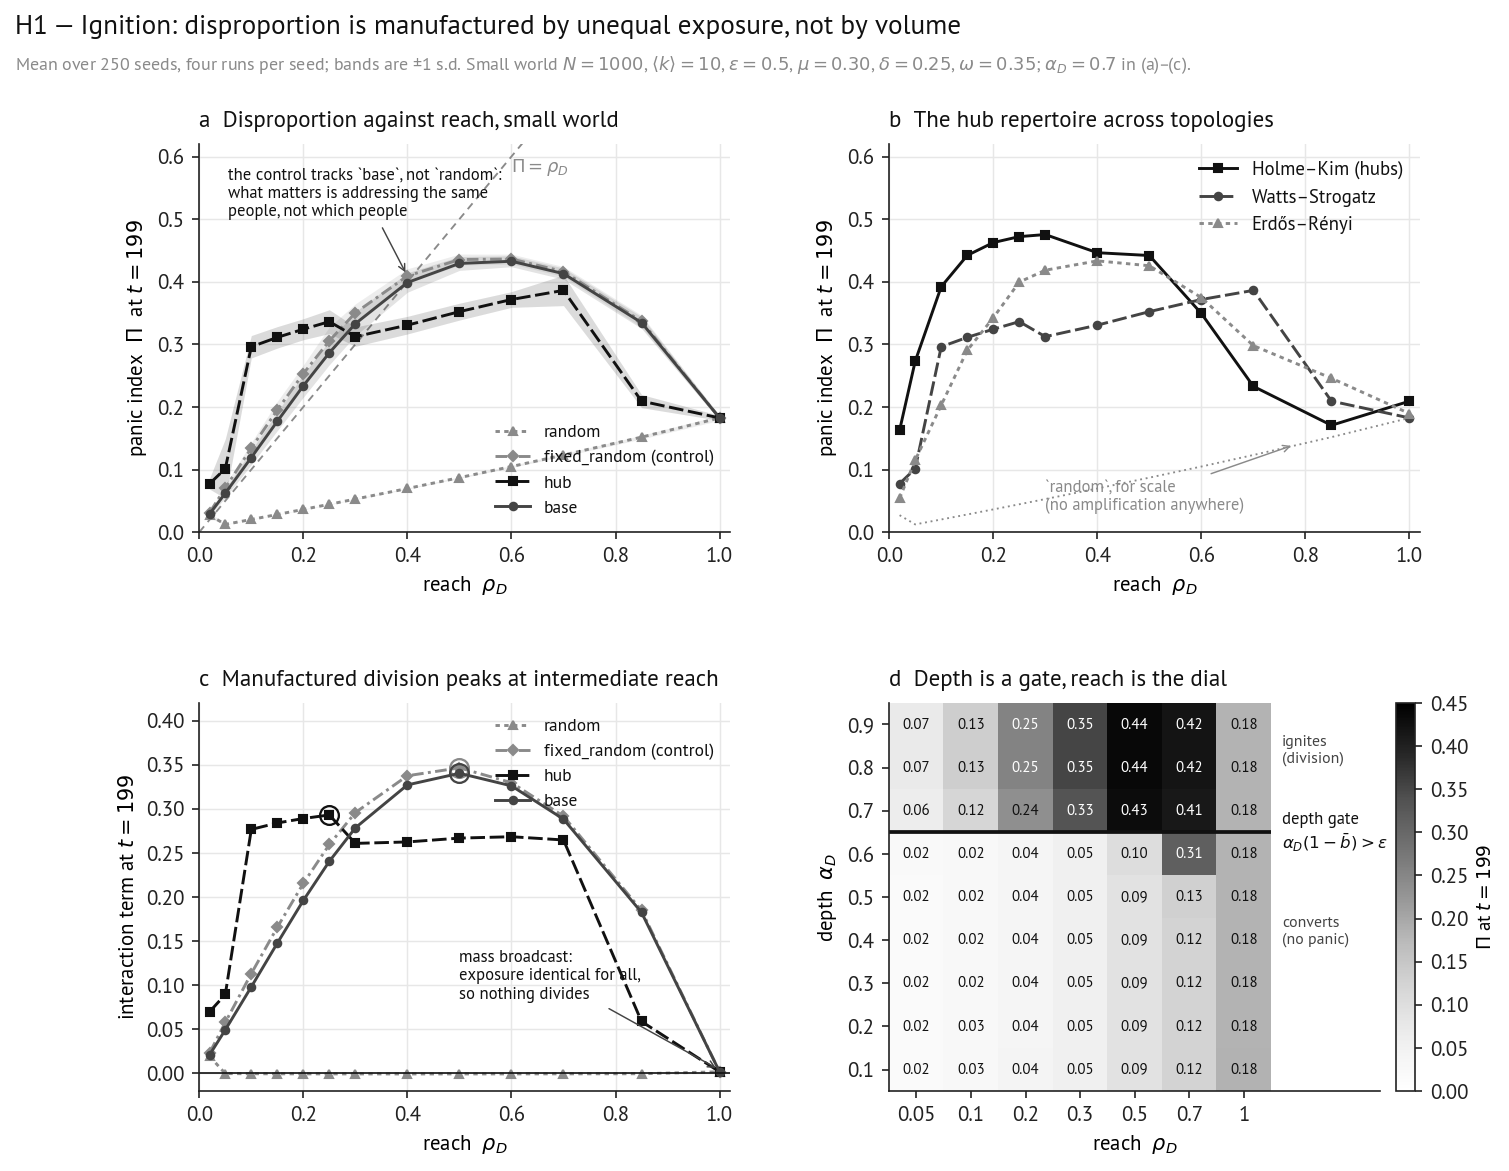

In [2]:
A1, A2, A5 = block(H1, "A1"), block(H1, "A2"), block(H1, "A5")

REP_STYLE = {                                   # repertoire → colour, dash, marker, label
    "random":       (MUTE, (0, (1.5, 1.5)),       "^", "random"),
    "fixed_random": (MUTE, (0, (4, 1.5, 1, 1.5)), "D", "fixed_random (control)"),
    "hub":          (INK,  (0, (5, 1.6)),         "s", "hub"),
    "base":         (MARK, "solid",               "o", "base"),
}

def repertoire_cells(repertoire, topology="watts_strogatz"):
    """A5 holds `fixed_random`; A1 holds the other three."""
    source = A5 if repertoire == "fixed_random" else A1
    return [c for c in source if c["label"]["topology"] == topology
            and c["label"]["repertoire"] == repertoire]
TOPO_STYLE = {
    "holme_kim":      (INK,  "solid",         "s", "Holme–Kim (hubs)"),
    "watts_strogatz": (MARK, (0, (5, 1.6)),   "o", "Watts–Strogatz"),
    "erdos_renyi":    (MUTE, (0, (1.5, 1.5)), "^", "Erdős–Rényi"),
}

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.2))
fig.subplots_adjust(hspace=0.44, wspace=0.30)

# (a) amplification by repertoire, small world --------------------------------
ax = tidy(axes[0, 0], "a  Disproportion against reach, small world",
          r"reach  $\rho_D$", r"panic index  $\Pi$  at $t=199$")
ax.plot([0, 1], [0, 1], color=MUTE, lw=0.9, ls=(0, (4, 3)), zorder=1)
for rep, (colour, dash, marker, label) in REP_STYLE.items():
    x, m, s = sweep(repertoire_cells(rep), "rho_d", "panic_index_at")
    ax.plot(x, m, color=colour, linestyle=dash, marker=marker, ms=3.6,
            lw=1.4, label=label, zorder=3)
    ax.fill_between(x, m - s, m + s, color=colour, alpha=0.15, lw=0, zorder=2)
ax.text(0.60, 0.575, r"$\Pi=\rho_D$", fontsize=8.6, color=MUTE)
ax.annotate("the control tracks `base`, not `random`:\nwhat matters is addressing the "
            "same\npeople, not which people", xy=(0.40, 0.409),
            xytext=(0.055, 0.505), fontsize=8.0, color=INK,
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.set_xlim(0, 1.02); ax.set_ylim(0, 0.62)
ax.legend(frameon=False, fontsize=8.4, loc="lower right")

# (b) hub across topologies ---------------------------------------------------
ax = tidy(axes[0, 1], "b  The hub repertoire across topologies",
          r"reach  $\rho_D$", r"panic index  $\Pi$  at $t=199$")
for topo, (colour, dash, marker, label) in TOPO_STYLE.items():
    cells = [c for c in A1 if c["label"]["topology"] == topo
             and c["label"]["repertoire"] == "hub"]
    x, m, _ = sweep(cells, "rho_d", "panic_index_at")
    ax.plot(x, m, color=colour, linestyle=dash, marker=marker, ms=3.6, lw=1.4, label=label)
x, m, _ = sweep(repertoire_cells("random"), "rho_d", "panic_index_at")
ax.plot(x, m, color=MUTE, lw=0.9, ls=(0, (1, 2)))
ax.annotate("`random`, for scale\n(no amplification anywhere)", xy=(0.78, 0.140),
            xytext=(0.30, 0.035), fontsize=8, color=MUTE,
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MUTE))
ax.set_xlim(0, 1.02); ax.set_ylim(0, 0.62)
ax.legend(frameon=False, fontsize=9, loc="upper right")

# (c) manufactured division ---------------------------------------------------
ax = tidy(axes[1, 0], "c  Manufactured division peaks at intermediate reach",
          r"reach  $\rho_D$", "interaction term at $t=199$")
for rep, (colour, dash, marker, label) in REP_STYLE.items():
    x, m, _ = sweep(repertoire_cells(rep), "rho_d", "interaction_at")
    ax.plot(x, m, color=colour, linestyle=dash, marker=marker, ms=3.6, lw=1.4, label=label)
    peak = int(np.argmax(m))
    if m[peak] > 0.05:
        ax.plot(x[peak], m[peak], marker="o", ms=9, mfc="none", mec=colour, mew=1.1)
ax.axhline(0, color=INK, lw=0.8)
ax.annotate("mass broadcast:\nexposure identical for all,\nso nothing divides",
            xy=(1.0, 0.004), xytext=(0.50, 0.085), fontsize=8, color=INK,
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.set_xlim(0, 1.02); ax.set_ylim(-0.02, 0.42)
ax.legend(frameon=False, fontsize=8.4, loc="upper right")

# (d) depth x reach -----------------------------------------------------------
ax = axes[1, 1]
alphas = sorted({c["label"]["alpha_d"] for c in A2})
rhos = sorted({c["label"]["rho_d"] for c in A2})
grid = np.array([[scalar(pick(A2, alpha_d=a, rho_d=r), "panic_index_at")[0]
                  for r in rhos] for a in alphas])
mesh = ax.imshow(grid, origin="lower", aspect="auto", cmap="Greys",
                 vmin=0, vmax=0.45, interpolation="nearest")
ax.set_xticks(range(len(rhos)), [f"{r:g}" for r in rhos])
ax.set_yticks(range(len(alphas)), [f"{a:g}" for a in alphas])
ax.grid(False)
for i in range(len(alphas)):
    for j in range(len(rhos)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=7.2,
                color="white" if grid[i, j] > 0.24 else INK)
gate = alphas.index(0.7) - 0.5
ax.plot([-0.5, len(rhos) - 0.5], [gate, gate], color=INK, lw=1.8, solid_capstyle="butt")
ax.set_xlim(-0.5, len(rhos) - 0.5 + 2.0)        # white margin for the gate label
ax.text(len(rhos) - 0.30, gate, "depth gate\n" + r"$\alpha_D(1-\bar b) > \epsilon$",
        fontsize=8, va="center", ha="left", color=INK)
ax.text(len(rhos) - 0.30, gate + 1.9, "ignites\n(division)", fontsize=7.6,
        va="center", ha="left", color=MARK)
ax.text(len(rhos) - 0.30, gate - 2.3, "converts\n(no panic)", fontsize=7.6,
        va="center", ha="left", color=MARK)
tidy(ax, "d  Depth is a gate, reach is the dial", r"reach  $\rho_D$", r"depth  $\alpha_D$")
fig.colorbar(mesh, ax=ax, fraction=0.045, pad=0.03).set_label(r"$\Pi$ at $t=199$", fontsize=9)

fig.suptitle("H1 — Ignition: disproportion is manufactured by unequal exposure, not by volume",
             x=0.008, ha="left", fontsize=13, fontweight="bold", y=0.985)
fig.text(0.008, 0.940, f"Mean over {len(META['seeds'])} seeds, four runs per seed; bands are ±1 s.d. "
         r"Small world $N=1000$, $\langle k\rangle=10$, $\epsilon=0.5$, "
         r"$\mu=0.30$, $\delta=0.25$, $\omega=0.35$; $\alpha_D=0.7$ in (a)–(c).",
         fontsize=8.6, color=MUTE, ha="left")
fig.savefig(FIGS / "fig1_h1_ignition.png", dpi=300, bbox_inches="tight")
plt.show()

**What the figure shows.** `random` never gets above the $\Pi=\rho_D$ diagonal — it converts
the population instead of dividing it, and its interaction term is zero to three decimals.
`hub` and `base` amplify, and `hub`'s advantage is largest in the hub-dominated graph, but it
does *not* collapse into `random` on the near-regular small world (degree s.d. 1.00), because
what it really exploits is a *fixed audience* rather than degree as such. Panel **c** shows
manufactured division vanishing at full reach: identical exposure divides nobody. Panel **d**
holds the sharpest structure in the experiment, and it is in the depth axis — below
$\alpha_D\approx0.7$ no amount of reach ignites, above it $\alpha_D$ stops mattering.

---

## Figure 2 — H2, handover

> *What starts a panic is not what sustains it.* The interaction term should overtake the
> entrepreneur's own signal, and post-withdrawal persistence should be governed by othering
> rather than by passive decay.

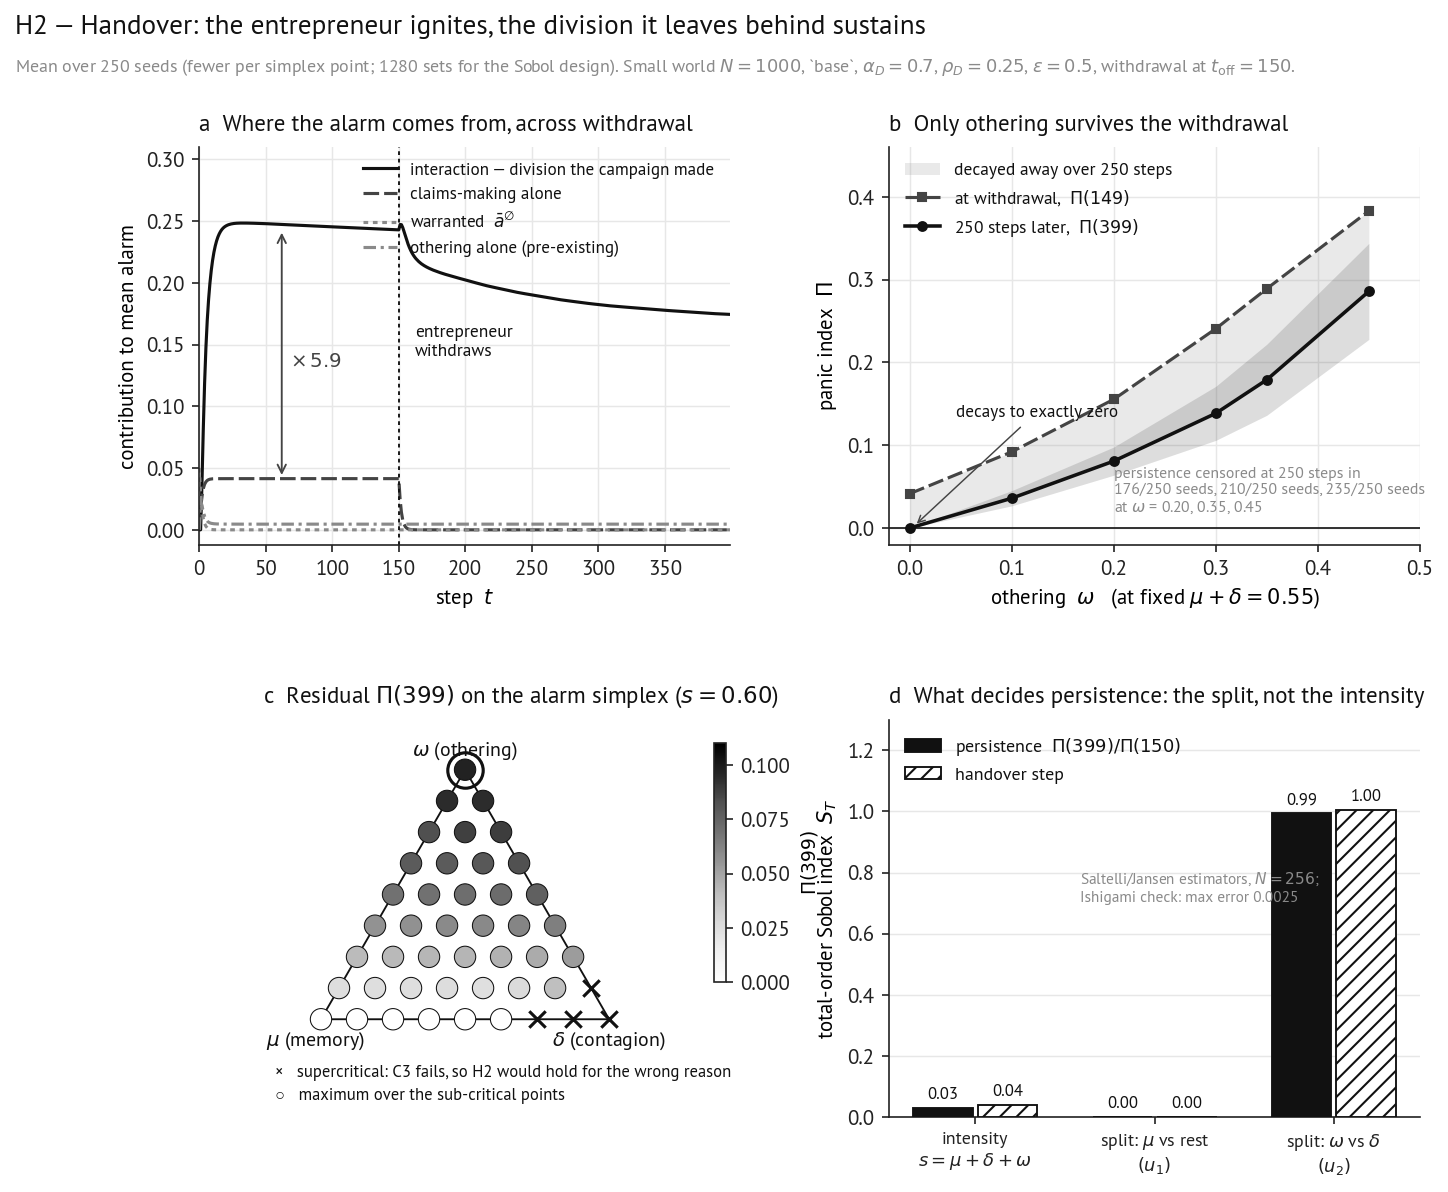

In [3]:
B1 = block(H2, "B1")[0]
B2, B6 = block(H2, "B2"), block(H2, "B6")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.4))
fig.subplots_adjust(hspace=0.44, wspace=0.30)

# (a) the four-way decomposition ----------------------------------------------
ax = tidy(axes[0, 0], "a  Where the alarm comes from, across withdrawal",
          "step  $t$", "contribution to mean alarm")
t = np.arange(len(curve(B1, "panic_index")))
for key, colour, dash, label in [
        ("interaction",    INK,  "solid",               "interaction — division the campaign made"),
        ("claims_alone",   MARK, (0, (5, 1.6)),         "claims-making alone"),
        ("warranted",      MUTE, (0, (1.5, 1.5)),       r"warranted  $\bar a^{\varnothing}$"),
        ("othering_alone", MUTE, (0, (4, 1.5, 1, 1.5)), "othering alone (pre-existing)")]:
    ax.plot(t, curve(B1, key), color=colour, linestyle=dash, lw=1.5, label=label)
ax.axvline(T_OFF, color=INK, lw=0.9, ls=(0, (2, 2)))
ax.annotate("entrepreneur\nwithdraws", xy=(T_OFF, 0.170), xytext=(T_OFF + 12, 0.166),
            fontsize=8.4, color=INK, va="top")
ax.annotate("", xy=(62, 0.244), xytext=(62, 0.041),
            arrowprops=dict(arrowstyle="<->", lw=0.9, color=MARK))
ax.text(68, 0.132, r"$\times\,5.9$", fontsize=9.5, color=MARK)
ax.set_xlim(0, t[-1]); ax.set_ylim(-0.012, 0.31)
ax.legend(frameon=False, fontsize=8.2, loc="upper right")

# (b) the othering floor -------------------------------------------------------
ax = tidy(axes[0, 1], "b  Only othering survives the withdrawal",
          r"othering  $\omega$   (at fixed $\mu+\delta=0.55$)", r"panic index  $\Pi$")
x, at_m, at_s = sweep(B2, "omega", "panic_index_at")
_, end_m, end_s = sweep(B2, "omega", "panic_index_end")
ax.fill_between(x, end_m, at_m, color=MUTE, alpha=0.18, lw=0,
                label="decayed away over 250 steps")
ax.plot(x, at_m, color=MARK, ls=(0, (5, 1.6)), marker="s", ms=4.2, lw=1.5,
        label=r"at withdrawal,  $\Pi(149)$")
ax.plot(x, end_m, color=INK, ls="solid", marker="o", ms=4.2, lw=1.7,
        label=r"250 steps later,  $\Pi(399)$")
ax.fill_between(x, end_m - end_s, end_m + end_s, color=INK, alpha=0.14, lw=0)
ax.axhline(0, color=INK, lw=0.8)
ax.annotate("decays to exactly zero", xy=(0.004, 0.002), xytext=(0.045, 0.135),
            fontsize=8.2, color=INK, arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
censored = {c["label"]["omega"]:
            f"{sum(s['persistence_censored'] for s in c['seeds'])}/{len(c['seeds'])}" for c in B2}
ax.text(0.20, 0.015, "persistence censored at 250 steps in\n"
        + ", ".join(f"{censored[w]} seeds" for w in (0.20, 0.35, 0.45))
        + "\n" + r"at $\omega$ = 0.20, 0.35, 0.45",
        fontsize=7.6, color=MUTE, va="bottom")
ax.set_xlim(-0.02, 0.50); ax.set_ylim(-0.02, 0.46)
ax.legend(frameon=False, fontsize=8.4, loc="upper left")

# (c) the alarm simplex ---------------------------------------------------------
ax = axes[1, 0]
sub = {(p["p_mu"], p["p_delta"], p["p_omega"]): p["subcritical"] for p in C3["points"]}
pts, vals, flags = [], [], []
for cell in B6:
    key = (cell["label"]["p_mu"], cell["label"]["p_delta"], cell["label"]["p_omega"])
    pts.append(key); vals.append(scalar(cell, "panic_index_end")[0])
    flags.append(bool(sub.get(key, True)))
pts, vals, flags = np.array(pts), np.array(vals), np.array(flags)
x = pts[:, 1] + 0.5 * pts[:, 2]                 # mu at (0,0), delta at (1,0), omega apex
y = (np.sqrt(3) / 2) * pts[:, 2]
ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color=INK, lw=0.9, zorder=2)
dots = ax.scatter(x[flags], y[flags], c=vals[flags], cmap="Greys", s=105, vmin=0, vmax=0.11,
                  edgecolors=INK, linewidths=0.5, zorder=3)
ax.scatter(x[~flags], y[~flags], marker="x", s=62, color=INK, linewidths=1.5, zorder=4)
best = int(np.argmax(np.where(flags, vals, -1)))
ax.plot(x[best], y[best], marker="o", ms=17, mfc="none", mec=INK, mew=1.5, zorder=5)
for label, (px, py), (dx, dy) in [(r"$\mu$ (memory)", (0, 0), (-0.02, -0.09)),
                                  (r"$\delta$ (contagion)", (1, 0), (0.0, -0.09)),
                                  (r"$\omega$ (othering)", (0.5, np.sqrt(3) / 2), (0, 0.05))]:
    ax.annotate(label, xy=(px, py), xytext=(px + dx, py + dy), fontsize=9.5,
                color=INK, ha="center")
ax.text(-0.16, -0.20, "\u00d7   supercritical: C3 fails, so H2 would hold for the wrong reason",
        fontsize=8, color=INK, ha="left")
ax.text(-0.16, -0.28, "\u25cb   maximum over the sub-critical points",
        fontsize=8, color=INK, ha="left")
ax.set_xlim(-0.20, 1.18); ax.set_ylim(-0.34, 1.04)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(r"c  Residual $\Pi(399)$ on the alarm simplex ($s=0.60$)", loc="left", pad=8,
             fontsize=11, fontweight="bold")
fig.colorbar(dots, ax=ax, fraction=0.030, pad=0.10, shrink=0.60,
             anchor=(0.0, 0.85)).set_label(r"$\Pi(399)$", fontsize=9)

# (d) Sobol indices ---------------------------------------------------------------
ax = tidy(axes[1, 1], "d  What decides persistence: the split, not the intensity",
          "", "total-order Sobol index  $S_T$")
names = SOBOL["input_names"]
pretty = {"s":  "intensity\n" + r"$s=\mu+\delta+\omega$",
          "u1": r"split: $\mu$ vs rest" + "\n" + r"$(u_1)$",
          "u2": r"split: $\omega$ vs $\delta$" + "\n" + r"$(u_2)$"}
width, positions = 0.36, np.arange(len(names))
for k, (key, colour, label, hatch) in enumerate([
        ("residual_ratio", INK, r"persistence  $\Pi(399)/\Pi(150)$", ""),
        ("handover_step", "white", "handover step", "///")]):
    heights = SOBOL["outputs"][key]["ST"]
    ax.bar(positions + (k - 0.5) * width, heights, width * 0.92, label=label,
           color=colour, edgecolor=INK, linewidth=0.9, hatch=hatch, zorder=3)
    for p, h in zip(positions + (k - 0.5) * width, heights):
        ax.text(p, h + 0.03, f"{h:.2f}", ha="center", fontsize=8, color=INK)
ax.set_xticks(positions, [pretty[n] for n in names], fontsize=8.6)
ax.set_ylim(0, 1.30); ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=8.6, loc="upper left")
ax.text(0.36, 0.62, "Saltelli/Jansen estimators, $N=256$;\nIshigami check: max error "
        f"{SOBOL['estimator_check']['max_abs_error']:.4f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=7.4, color=MUTE)

fig.suptitle("H2 — Handover: the entrepreneur ignites, the division it leaves behind sustains",
             x=0.008, ha="left", fontsize=13, fontweight="bold", y=0.985)
fig.text(0.008, 0.940, f"Mean over {len(META['seeds'])} seeds (fewer per simplex point; 1280 sets for the Sobol "
         r"design). Small world $N=1000$, `base`, $\alpha_D=0.7$, $\rho_D=0.25$, "
         r"$\epsilon=0.5$, withdrawal at $t_{\mathrm{off}}=150$.",
         fontsize=8.6, color=MUTE, ha="left")
fig.savefig(FIGS / "fig2_h2_handover.png", dpi=300, bbox_inches="tight")
plt.show()

**What the figure shows.** The interaction term overtakes claims-alone at $t=2$ — the first
step at which §10.1 permits it to be non-zero — and holds a factor of 5.9 over it for the
rest of the campaign; othering-alone never leaves 0.005, so nothing here is inherited from
the population's initial dispersion. In panel **b** the gap between the two lines is what
decayed away and the lower line is the floor that did not: at $\omega=0$ the floor is exactly
zero, and it rises monotonically with $\omega$. Panel **c** is the result that needed the C3
audit — the four crossed points are supercritical and carry the *highest* raw persistence in
the scan, and once they are removed the maximum sits exactly on the $\omega$ vertex. Panel
**d** puts a number on it: the split between memory, contagion and othering carries
essentially all the variance in persistence, the total intensity carries 3%.

---

## Figure 3 — H3, defense

> *Answering back need not lower the alarm, and may raise it.* Both branches were fixed in
> advance: either broad-and-shallow lowers $\Pi$ while narrow-and-deep raises it, or no
> configuration lowers it at all.

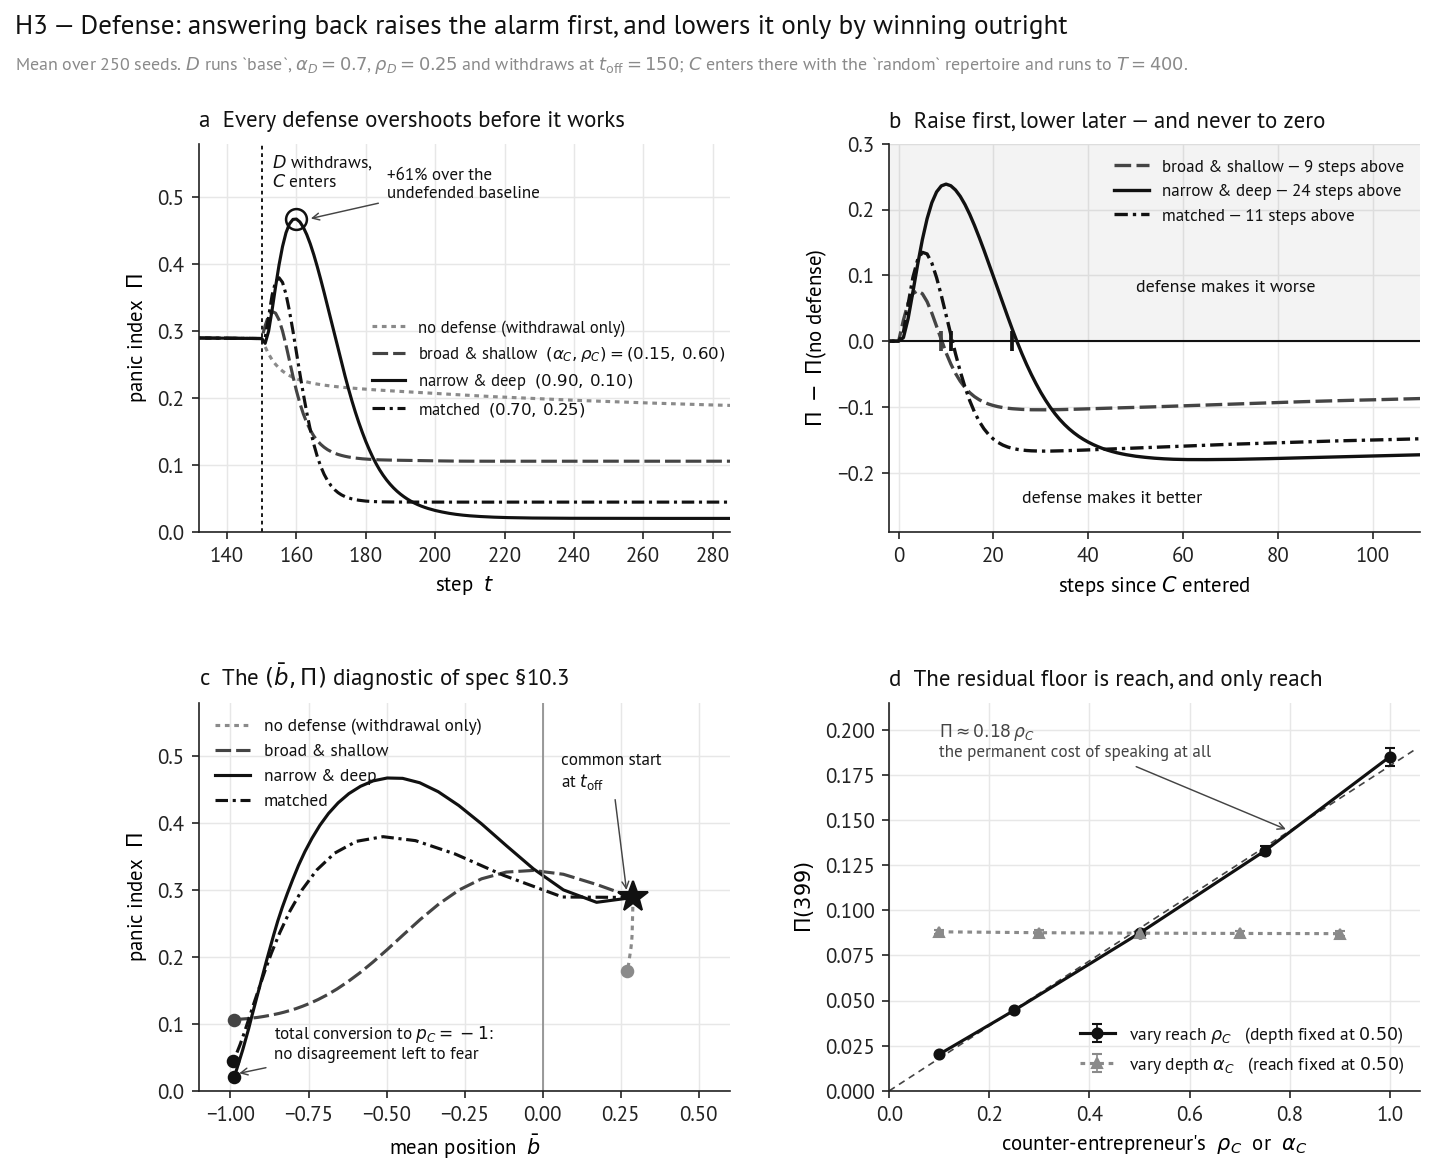

In [4]:
C1, C2 = block(H3, "C1"), block(H3, "C2")
CONFIGS = [("none",          MUTE, (0, (1.5, 1.5)),       "no defense (withdrawal only)"),
           ("broad_shallow", MARK, (0, (5, 1.6)),         "broad & shallow"),
           ("narrow_deep",   INK,  "solid",               "narrow & deep"),
           ("matched",       INK,  (0, (4, 1.5, 1, 1.5)), "matched")]
DETAIL = {"none": "", "broad_shallow": r"  $(\alpha_C,\rho_C)=(0.15,\,0.60)$",
          "narrow_deep": r"  $(0.90,\,0.10)$", "matched": r"  $(0.70,\,0.25)$"}

traces = {name: {k: curve(pick(C1, configuration=name), k)
                 for k in ("panic_index", "mean_position")} for name, *_ in CONFIGS}
t = np.arange(len(traces["none"]["panic_index"]))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.2))
fig.subplots_adjust(hspace=0.44, wspace=0.30)

# (a) the panic index around entry ---------------------------------------------
ax = tidy(axes[0, 0], "a  Every defense overshoots before it works",
          "step  $t$", r"panic index  $\Pi$")
for name, colour, dash, label in CONFIGS:
    ax.plot(t, traces[name]["panic_index"], color=colour, linestyle=dash, lw=1.5,
            label=label + DETAIL[name])
ax.axvline(T_OFF, color=INK, lw=0.9, ls=(0, (2, 2)))
ax.text(T_OFF + 3, 0.567, "$D$ withdraws,\n$C$ enters", fontsize=8.4,
        color=INK, ha="left", va="top")
peak = int(np.argmax(traces["narrow_deep"]["panic_index"]))
ax.plot(peak, traces["narrow_deep"]["panic_index"][peak], marker="o", ms=10,
        mfc="none", mec=INK, mew=1.2)
ax.annotate("+61% over the\nundefended baseline", xy=(peak + 3, 0.467),
            xytext=(peak + 26, 0.50), fontsize=8.2, color=INK,
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.set_xlim(132, 285); ax.set_ylim(0, 0.58)
ax.legend(frameon=False, fontsize=8.0, loc="center right", bbox_to_anchor=(1.02, 0.42))

# (b) excess over the undefended baseline ----------------------------------------
ax = tidy(axes[0, 1], "b  Raise first, lower later — and never to zero",
          "steps since $C$ entered", r"$\Pi\;-\;\Pi$(no defense)")
ax.axhspan(0, 0.30, color=MUTE, alpha=0.10, lw=0)
for name, colour, dash, label in CONFIGS[1:]:
    excess = traces[name]["panic_index"] - traces["none"]["panic_index"]
    crossing = int((excess[T_OFF:] > 0).sum())
    ax.plot(t - T_OFF, excess, color=colour, linestyle=dash, lw=1.6,
            label=f"{label} — {crossing} steps above")
    ax.plot(crossing, 0.0, marker="|", ms=10, color=colour, mew=1.8)
ax.axhline(0, color=INK, lw=1.0)
ax.text(50, 0.075, "defense makes it worse", fontsize=8.6, color=INK)
ax.text(26, -0.245, "defense makes it better", fontsize=8.6, color=INK)
ax.set_xlim(-2, 110); ax.set_ylim(-0.29, 0.30)
ax.legend(frameon=False, fontsize=8.2, loc="upper right")

# (c) the (b, Pi) diagnostic --------------------------------------------------------
ax = tidy(axes[1, 0], r"c  The $(\bar b,\Pi)$ diagnostic of spec §10.3",
          r"mean position  $\bar b$", r"panic index  $\Pi$")
for name, colour, dash, label in CONFIGS:
    path_b = traces[name]["mean_position"][T_OFF:]
    path_p = traces[name]["panic_index"][T_OFF:]
    ax.plot(path_b, path_p, color=colour, linestyle=dash, lw=1.5, label=label)
    ax.plot(path_b[-1], path_p[-1], marker="o", ms=5.5, color=colour, zorder=4)
ax.plot(traces["none"]["mean_position"][T_OFF], traces["none"]["panic_index"][T_OFF],
        marker="*", ms=15, color=INK, zorder=5)
ax.annotate("common start\nat $t_{\\mathrm{off}}$", xy=(0.27, 0.294), xytext=(0.06, 0.455),
            fontsize=8.2, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.annotate("total conversion to $p_C=-1$:\nno disagreement left to fear",
            xy=(-0.985, 0.025), xytext=(-0.86, 0.048), fontsize=8.2, color=INK,
            ha="left", arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.axvline(0, color=MUTE, lw=0.8)
ax.set_xlim(-1.10, 0.60); ax.set_ylim(0, 0.58)
ax.legend(frameon=False, fontsize=8.4, loc="upper left")

# (d) the two channels ---------------------------------------------------------------
ax = tidy(axes[1, 1], "d  The residual floor is reach, and only reach",
          r"counter-entrepreneur's  $\rho_C$  or  $\alpha_C$", r"$\Pi(399)$")
grid_x = np.linspace(0, 1.05, 20)
ax.plot(grid_x, 0.18 * grid_x, color=MARK, lw=0.8, ls=(0, (4, 3)), zorder=1)
for axis, colour, dash, marker, label in [
        ("rho_c", INK, "solid", "o", r"vary reach $\rho_C$   (depth fixed at $0.50$)"),
        ("alpha_c", MUTE, (0, (1.5, 1.5)), "^", r"vary depth $\alpha_C$   (reach fixed at $0.50$)")]:
    cells = [c for c in C2 if c["label"]["axis"] == axis]
    x, m, s = sweep(cells, "value", "panic_index_end")
    ax.errorbar(x, m, yerr=s, color=colour, linestyle=dash, marker=marker, ms=4.8,
                lw=1.5, capsize=2.5, elinewidth=0.8, label=label, zorder=3)
ax.annotate(r"$\Pi \approx 0.18\,\rho_C$" + "\nthe permanent cost of speaking at all",
            xy=(0.80, 0.144), xytext=(0.10, 0.185), fontsize=8.2, color=MARK,
            arrowprops=dict(arrowstyle="->", lw=0.7, color=MARK))
ax.set_xlim(0, 1.06); ax.set_ylim(0, 0.215)
ax.legend(frameon=False, fontsize=8.4, loc="lower right")

fig.suptitle("H3 — Defense: answering back raises the alarm first, and lowers it only by winning outright",
             x=0.008, ha="left", fontsize=13, fontweight="bold", y=0.985)
fig.text(0.008, 0.940, f"Mean over {len(META['seeds'])} seeds. $D$ runs `base`, "
         r"$\alpha_D=0.7$, $\rho_D=0.25$ and withdraws at $t_{\mathrm{off}}=150$; "
         r"$C$ enters there with the `random` repertoire and runs to $T=400$.",
         fontsize=8.6, color=MUTE, ha="left")
fig.savefig(FIGS / "fig3_h3_defense.png", dpi=300, bbox_inches="tight")
plt.show()

**What the figure shows.** Neither pre-registered branch survives. Every configuration raises
$\Pi$ for 9–24 steps and then lowers it permanently, so the answer is a sequence, not a sign.
The largest overshoot belongs to the configuration with the *smallest* reach — narrow & deep,
+61% over the undefended baseline — which is H3's second channel working exactly as
described: taking 10% of the population to $-1$ in one step does not narrow moral distance to
a bulk sitting at $+0.29$, it maximises it. Panel **c** shows how the eventual reduction is
achieved: total conversion to $C$'s own pole, after which there is no disagreement left to be
alarmed by. Panel **d** shows the price of that victory — a permanent floor of $0.18\rho_C$,
linear in reach and flat in depth, because every claims-maker enters the alarm neighbourhood
of everyone it reaches as a maximally alarmed contact.

---

### Figures written

`figures/fig1_h1_ignition.png`, `figures/fig2_h2_handover.png` and
`figures/fig3_h3_defense.png`, at 300 dpi.